# 🍎 FreshGuard — Notebook 03: LSTM Spoilage Forecast

**Forecasting workstream**

The manager dashboard needs a 7-day forward look at daily flagged-item counts (reject + sell-soon). This notebook:

1. Generates the same simulated scan history the backend uses
2. Trains an LSTM: 28-day lookback → 7-day forecast
3. Benchmarks it against a seasonal-naive baseline
4. Exports the trained model and history so the dashboard switches from fallback to live predictions

> **Note:** The history is simulated (labelled clearly in the deck and Q&A).
> Real scan data would replace it once the app has been running in-store.


## ⚙️ Section 1 — Setup & Imports

In [ ]:
# Colab: uncomment if first run
!pip install -q tensorflow scikit-learn

import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Paths ────────────────────────────────────────────────────────────────────
ROOT       = Path("/content/Deep-Learning-Computer-Vision")
MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ── Forecast hyperparameters ─────────────────────────────────────────────────
WINDOW  = 28   # days the model looks back
HORIZON = 7    # days it predicts forward

print(f"TensorFlow {tf.__version__}")
print(f"Models dir: {MODELS_DIR}  (exists: {MODELS_DIR.exists()})")

TensorFlow 2.20.0
Models dir: /content/Deep-Learning-Computer-Vision/models  (exists: True)


## 📊 Section 2 — Simulate History & Export CSV

We generate ~2 years of daily flagged-item counts (reject + sell-soon) using the
**exact same function** as `backend/forecast.py`. Keeping the seed and generator
identical ensures the history chart in the dashboard matches the data the LSTM
was trained on — no seam between the notebook and the live app.

The series has three components the LSTM needs to learn:
- **Weekly seasonality** — weekend spikes (delivery cycles)
- **Yearly seasonality** — summer freshness bump
- **Trend** — slow store growth over time

> This data is simulated. In production it would be replaced by real scan logs
> once the app has been running in-store.

Exported 730 rows → /content/Deep-Learning-Computer-Vision/models/scan_history.csv
          date  flagged_items
727 2026-06-10           68.6
728 2026-06-11           60.7
729 2026-06-12           66.0


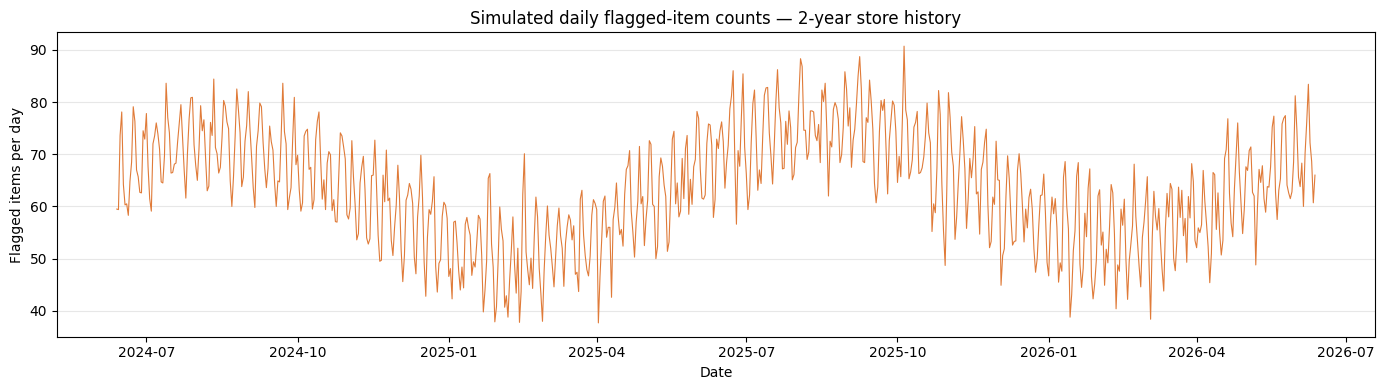

In [ ]:
def simulate_history(days: int = 730, seed: int = 42) -> pd.DataFrame:
    """
    Generate a synthetic daily time series of flagged produce items for one store.

    Copied verbatim from backend/forecast.py — seed and generator must stay
    in sync so the dashboard chart matches the data this notebook trains on.

    Parameters
    ----------
    days : int
        Number of daily observations to generate.
    seed : int
        RNG seed for reproducibility.

    Returns
    -------
    df : pd.DataFrame
        DataFrame with columns 'date' (datetime) and 'flagged_items' (float).
    """
    rng = np.random.default_rng(seed)
    t = np.arange(days)
    weekly = 8 * np.sin(2 * np.pi * t / 7 - 1.2)       # weekend spikes
    yearly = 12 * np.sin(2 * np.pi * t / 365 + 0.5)    # summer bump
    trend  = 0.01 * t                                    # store growth
    base   = 60
    counts = base + weekly + yearly + trend + rng.normal(0, 4, days)
    dates  = pd.date_range(end=pd.Timestamp.today().normalize(), periods=days)
    return pd.DataFrame({"date": dates, "flagged_items": counts.clip(min=0).round(1)})


df = simulate_history(days=730, seed=SEED)

# Export — backend/forecast.py picks this up automatically once it exists
df.to_csv(MODELS_DIR / "scan_history.csv", index=False)
print(f"Exported {len(df)} rows → {MODELS_DIR / 'scan_history.csv'}")
print(df.tail(3))

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["date"], df["flagged_items"], linewidth=0.8, color="#e07b39")
ax.set_title("Simulated daily flagged-item counts — 2-year store history")
ax.set_xlabel("Date")
ax.set_ylabel("Flagged items per day")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 🔍 Section 3 — Exploratory Look at the Series

Before modelling, we identify the temporal structures the LSTM needs to capture.
Two observations justify our architecture and hyperparameter choices:

- **Weekly seasonality** (period = 7 days) — justifies a 28-day window (4 full cycles)
- **Yearly seasonality + trend** — justifies LSTM over a vanilla RNN, whose vanishing
  gradients struggle with dependencies longer than ~10 steps

We keep this section brief — the goal is architectural justification, not a full EDA.

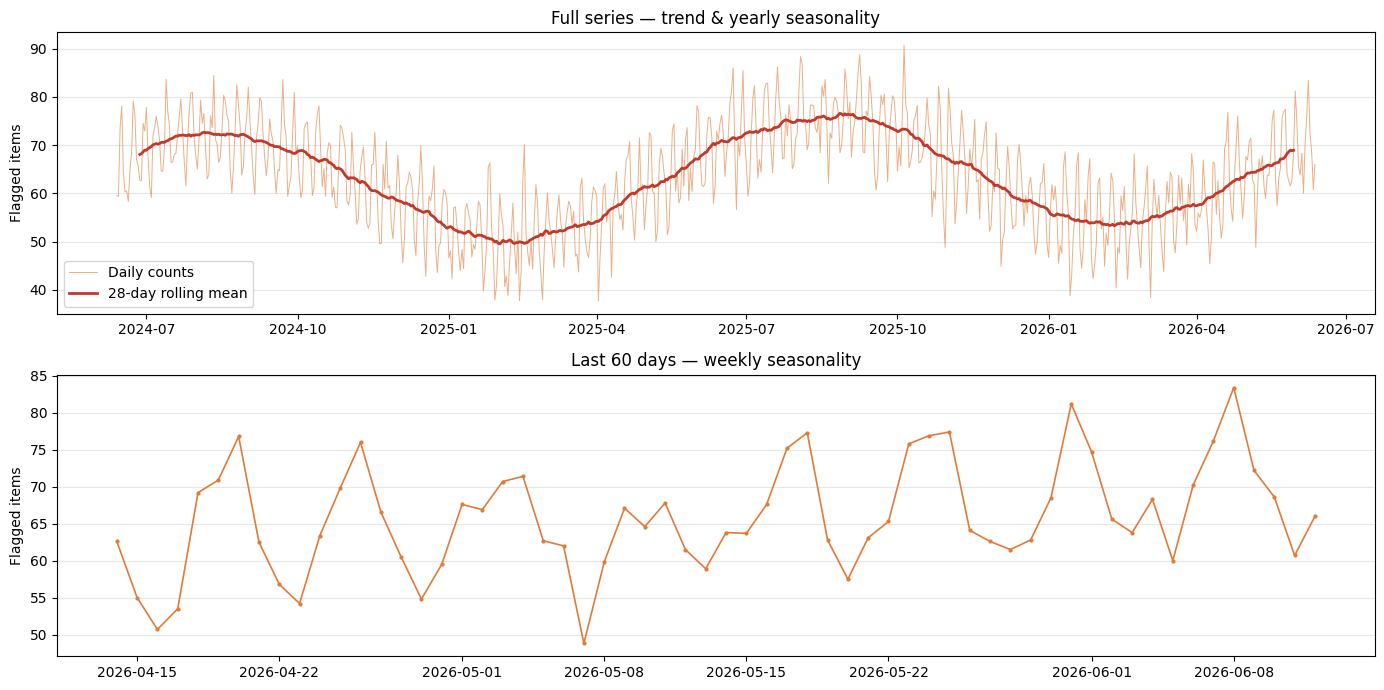

Series length : 730 days
Mean          : 63.4  |  Std: 10.5
Min           : 37.7  |  Max: 90.7


In [ ]:
series = df["flagged_items"].values

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# ── Full series with 28-day rolling mean to expose trend + yearly pattern ────
rolling = df["flagged_items"].rolling(28, center=True).mean()
axes[0].plot(df["date"], series, linewidth=0.7, alpha=0.6,
             color="#e07b39", label="Daily counts")
axes[0].plot(df["date"], rolling, linewidth=2,
             color="#c0392b", label="28-day rolling mean")
axes[0].set_title("Full series — trend & yearly seasonality")
axes[0].set_ylabel("Flagged items")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# ── 60-day zoom to expose the weekly cycle ───────────────────────────────────
axes[1].plot(df["date"].iloc[-60:], series[-60:],
             linewidth=1.2, color="#e07b39", marker="o", markersize=2)
axes[1].set_title("Last 60 days — weekly seasonality")
axes[1].set_ylabel("Flagged items")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Series length : {len(series)} days")
print(f"Mean          : {series.mean():.1f}  |  Std: {series.std():.1f}")
print(f"Min           : {series.min():.1f}  |  Max: {series.max():.1f}")

## ✂️ Section 4 — Chronological Split

We split the series into **train (70%) / validation (15%) / test (15%)** strictly by time position — earlier data trains the model, later data evaluates it.

**Never shuffle a time series.** A random split would let the model train on
future observations and validate on past ones — the metrics would look great but
the model would be useless in production (it can't see the future at inference time).

| Split | Portion | Purpose |
|---|---|---|
| Train | Days 1–511 | Model learns the pattern |
| Validation | Days 512–621 | Early stopping & hyperparameter tuning |
| Test | Days 622–730 | Final unbiased evaluation |


Total  : 730 days
Train  : 510 days  (2024-06-13 → 2025-11-04)
Val    : 110 days  (2025-11-05 → 2026-02-22)
Test   : 110 days  (2026-02-23 → 2026-06-12)


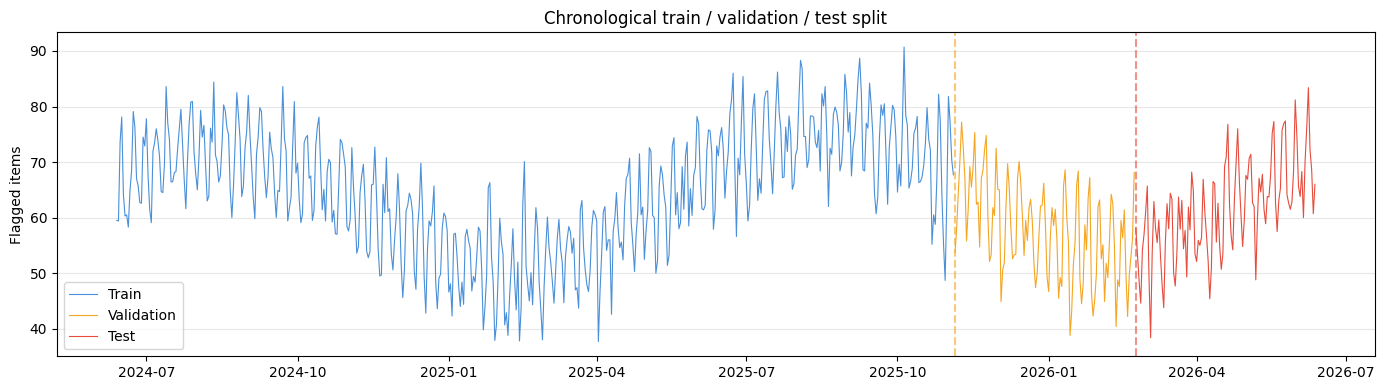

In [ ]:
n         = len(series)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_raw = series[:train_end]
val_raw   = series[train_end:val_end]
test_raw  = series[val_end:]

print(f"Total  : {n} days")
print(f"Train  : {len(train_raw)} days  ({df['date'].iloc[0].date()} → {df['date'].iloc[train_end-1].date()})")
print(f"Val    : {len(val_raw)} days  ({df['date'].iloc[train_end].date()} → {df['date'].iloc[val_end-1].date()})")
print(f"Test   : {len(test_raw)} days  ({df['date'].iloc[val_end].date()} → {df['date'].iloc[-1].date()})")

# ── Visualise the split ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["date"].iloc[:train_end],  train_raw, color="#4a90d9", linewidth=0.8, label="Train")
ax.plot(df["date"].iloc[train_end:val_end], val_raw, color="#f5a623", linewidth=0.8, label="Validation")
ax.plot(df["date"].iloc[val_end:],    test_raw,  color="#e74c3c", linewidth=0.8, label="Test")
ax.axvline(df["date"].iloc[train_end], color="#f5a623", linestyle="--", alpha=0.6)
ax.axvline(df["date"].iloc[val_end],   color="#e74c3c",  linestyle="--", alpha=0.6)
ax.set_title("Chronological train / validation / test split")
ax.set_ylabel("Flagged items")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## ⚖️ Section 5 — Scaling

LSTMs are sensitive to input magnitude — large raw values slow convergence and
can destabilise gradients. We normalise the series to [0, 1] using `MinMaxScaler`.

**Critical rule:** fit the scaler on the training set only, then apply it to
validation and test. Fitting on the full series would leak the future min/max
into training — the model would effectively know the range of values it hasn't
seen yet.

In [ ]:
scaler = MinMaxScaler()

# fit on training data only to prevent leakage
train_scaled = scaler.fit_transform(train_raw.reshape(-1, 1)).flatten()
val_scaled   = scaler.transform(val_raw.reshape(-1, 1)).flatten()
test_scaled  = scaler.transform(test_raw.reshape(-1, 1)).flatten()

print(f"Scaler fit on train — min: {scaler.data_min_[0]:.1f}, max: {scaler.data_max_[0]:.1f}")
print(f"Train scaled range : [{train_scaled.min():.3f}, {train_scaled.max():.3f}]")
print(f"Val   scaled range : [{val_scaled.min():.3f}, {val_scaled.max():.3f}]")
print(f"Test  scaled range : [{test_scaled.min():.3f}, {test_scaled.max():.3f}]")

Scaler fit on train — min: 37.7, max: 90.7
Train scaled range : [0.000, 1.000]
Val   scaled range : [0.021, 0.745]
Test  scaled range : [0.013, 0.862]


## 🪟 Section 6 — Windowing

We convert the scaled series into supervised samples: for each position,
take the **previous 28 days as input (X)** and the **next 7 days as the target (y)**.

This is how a flat time series becomes a dataset an LSTM can train on.

| | Shape | Meaning |
|---|---|---|
| `X` | `(samples, 28, 1)` | 28-day lookback window, 1 feature |
| `y` | `(samples, 7)` | 7-day forecast horizon |

The 28-day window captures 4 full weekly cycles — enough context for the LSTM
to recognise both the weekly pattern and the position within the yearly wave.

In [ ]:
def make_windows(series: np.ndarray, window: int = WINDOW,
                 horizon: int = HORIZON) -> tuple[np.ndarray, np.ndarray]:
    """
    Slice a 1-D time series into overlapping (X, y) supervised samples.

    Parameters
    ----------
    series : np.ndarray
        Scaled 1-D time series.
    window : int
        Number of past timesteps used as input features.
    horizon : int
        Number of future timesteps to predict.

    Returns
    -------
    X : np.ndarray, shape (samples, window, 1)
        Input sequences — last axis added for LSTM's expected feature dimension.
    y : np.ndarray, shape (samples, horizon)
        Target sequences immediately following each input window.
    """
    X, y = [], []
    for i in range(len(series) - window - horizon + 1):
        X.append(series[i : i + window])
        y.append(series[i + window : i + window + horizon])
    # add feature dimension: (samples, timesteps) → (samples, timesteps, 1)
    return np.array(X)[..., np.newaxis], np.array(y)


X_train, y_train = make_windows(train_scaled)
X_val,   y_val   = make_windows(val_scaled)
X_test,  y_test  = make_windows(test_scaled)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}  y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}  y_test : {y_test.shape}")

X_train: (476, 28, 1)  y_train: (476, 7)
X_val  : (76, 28, 1)  y_val  : (76, 7)
X_test : (76, 28, 1)  y_test : (76, 7)


## 📏 Section 7 — Naive Baseline

Before training the LSTM, we establish the bar it needs to beat.

The **seasonal naive baseline** predicts that each future day will equal the
average of the same weekday over the last 4 weeks. It's a strong baseline for
weekly-seasonal data — simple, interpretable, and hard to beat without a real model.

We compute **MAE** and **RMSE** in real units (inverse-transformed) so the
numbers are interpretable as actual flagged-item counts.

In [ ]:
def seasonal_naive_forecast(series_raw: np.ndarray, window: int = WINDOW,
                             horizon: int = HORIZON) -> tuple[np.ndarray, np.ndarray]:
    """
    Generate seasonal-naive forecasts for every test window in the raw series.

    For each position, predicts each future day as the mean of the same
    weekday across the last 4 weeks of the lookback window.

    Parameters
    ----------
    series_raw : np.ndarray
        Raw (unscaled) time series values.
    window : int
        Lookback window length — must match the LSTM window.
    horizon : int
        Number of days to forecast ahead.

    Returns
    -------
    y_true : np.ndarray, shape (samples, horizon)
        Actual future values for each window.
    y_pred : np.ndarray, shape (samples, horizon)
        Seasonal-naive predictions for each window.
    """
    y_true, y_pred = [], []
    for i in range(len(series_raw) - window - horizon + 1):
        lookback = series_raw[i : i + window]
        actual   = series_raw[i + window : i + window + horizon]
        forecast = [float(np.mean(lookback[-(7 * k):][::7][:4]))
                    for k in range(1, horizon + 1)]
        y_true.append(actual)
        y_pred.append(forecast)
    return np.array(y_true), np.array(y_pred)


# Baseline evaluated on the raw test series (same slice as X_test/y_test)
test_raw_slice = series[val_end:]
y_true_base, y_pred_base = seasonal_naive_forecast(test_raw_slice)

baseline_mae  = mean_absolute_error(y_true_base, y_pred_base)
baseline_rmse = np.sqrt(mean_squared_error(y_true_base, y_pred_base))

print("Seasonal-naive baseline (test set, real units)")
print(f"  MAE  : {baseline_mae:.2f} flagged items/day")
print(f"  RMSE : {baseline_rmse:.2f} flagged items/day")

Seasonal-naive baseline (test set, real units)
  MAE  : 7.73 flagged items/day
  RMSE : 9.59 flagged items/day


## 🧠 Section 8 — Build, Train & Export LSTM

We build a single-layer **LSTM(64)** followed by a `Dense(7)` output — one unit
per forecast day. This is intentionally compact: the series has clear structure
and only 476 training samples, so a larger model would overfit rather than generalise.

Training uses:
- **MSE loss** — standard for regression; penalises large errors more than MAE
- **EarlyStopping** — halts when validation loss stops improving (patience = 10)
- **ReduceLROnPlateau** — halves the learning rate if val loss plateaus (patience = 5)

After training we:
1. Plot train vs. validation loss — overfitting evidence for the rubric
2. Evaluate on the test set in **real units** (inverse-transformed)
3. Plot predicted vs. actual — the key demo artifact
4. Print the final comparison table vs. the baseline
5. Export `models/spoilage_lstm.keras` — the backend picks it up automatically

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, input_shape=(WINDOW, 1)),
    tf.keras.layers.Dense(HORIZON)
], name="spoilage_lstm")

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1,
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "spoilage_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,351 (67.78 KB)

 Trainable params: 17,351 (67.78 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 155ms/step - loss: 0.1571 - mae: 0.3355 - val_loss: 0.0627 - val_mae: 0.2060 - learning_rate: 0.0010
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0303 - mae: 0.1394 - val_loss: 0.0243 - val_mae: 0.1291 - learning_rate: 0.0010
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.0215 - mae: 0.1188 - val_loss: 0.0214 - val_mae: 0.1219 - learning_rate: 0.0010
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0193 - mae: 0.1131 - val_loss: 0.0217 - val_mae: 0.1225 - learning_rate: 0.0010
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0187 - mae: 0.1115 - val_loss: 0.0211 - val_mae: 0.1211 - learning_rate: 0.0010
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 0.0183 - mae: 0.1103 - val_loss: 0.0206 - val_mae: 0.1197 - learning_rate: 0.0010
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0182 - mae: 0.1101 - val_loss: 0.0202 - val_mae: 0.1189 - learning_rate: 0.0010
Epoch

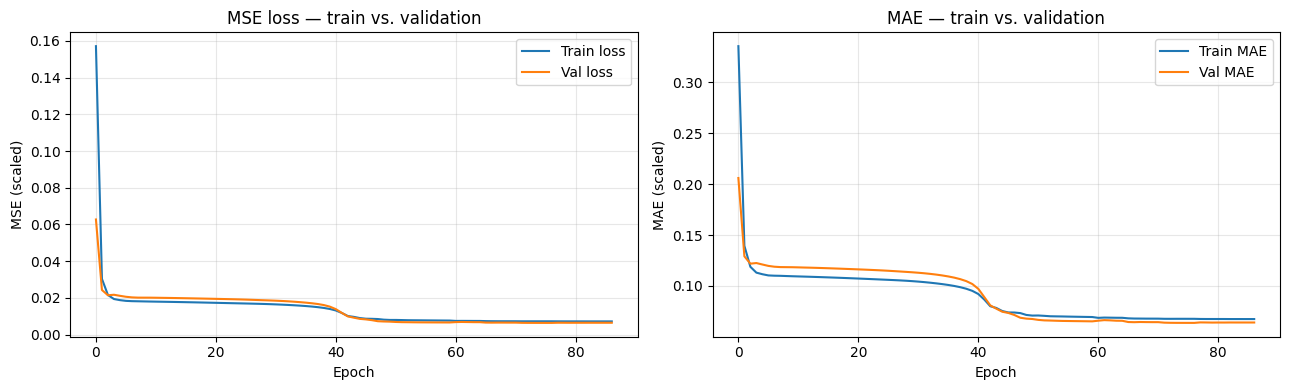

Training stopped at epoch 87


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history["loss"],     label="Train loss")
axes[0].plot(history.history["val_loss"], label="Val loss")
axes[0].set_title("MSE loss — train vs. validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE (scaled)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history["mae"],     label="Train MAE")
axes[1].plot(history.history["val_mae"], label="Val MAE")
axes[1].set_title("MAE — train vs. validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE (scaled)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Training stopped at epoch {len(history.history['loss'])}")

In [ ]:
# Predict on test set and inverse-transform back to real units
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred_real   = scaler.inverse_transform(y_pred_scaled)
y_true_real   = scaler.inverse_transform(y_test)

lstm_mae  = mean_absolute_error(y_true_real, y_pred_real)
lstm_rmse = np.sqrt(mean_squared_error(y_true_real, y_pred_real))

print("─" * 45)
print(f"{'Model':<22} {'MAE':>8} {'RMSE':>10}")
print("─" * 45)
print(f"{'Seasonal naive':<22} {baseline_mae:>8.2f} {baseline_rmse:>10.2f}")
print(f"{'LSTM':<22} {lstm_mae:>8.2f} {lstm_rmse:>10.2f}")
print("─" * 45)
print(f"MAE improvement : {((baseline_mae - lstm_mae) / baseline_mae) * 100:.1f}%")

─────────────────────────────────────────────
Model                       MAE       RMSE
─────────────────────────────────────────────
Seasonal naive             7.73       9.59
LSTM                       4.14       5.05
─────────────────────────────────────────────
MAE improvement : 46.5%


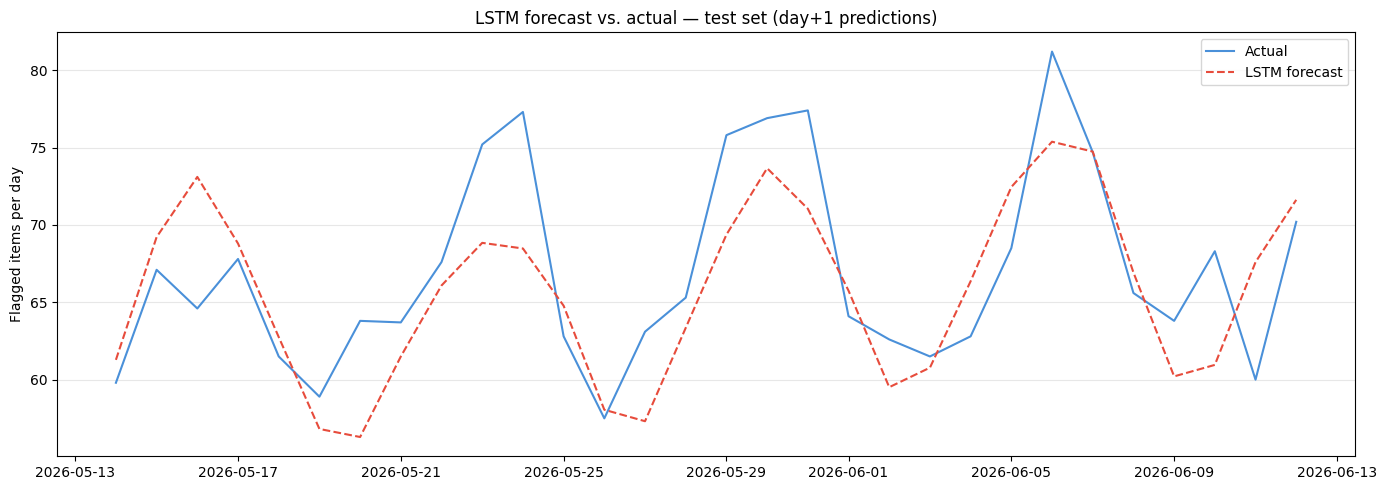

This plot shows the first day of each 7-day window for clarity.


In [ ]:
# Plot the last 30 test windows' day-1 forecasts against actuals
n_plot   = 30
actuals  = y_true_real[-n_plot:, 0]
preds    = y_pred_real[-n_plot:, 0]
dates_test = df["date"].iloc[val_end + WINDOW:].reset_index(drop=True)
plot_dates = dates_test.iloc[-n_plot:]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(plot_dates, actuals, label="Actual",    color="#4a90d9", linewidth=1.5)
ax.plot(plot_dates, preds,   label="LSTM forecast", color="#e74c3c",
        linewidth=1.5, linestyle="--")
ax.set_title("LSTM forecast vs. actual — test set (day+1 predictions)")
ax.set_ylabel("Flagged items per day")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
print("This plot shows the first day of each 7-day window for clarity.")

In [30]:
from google.colab import drive
import shutil
import os

drive.mount('/content/drive', force_remount=False)

# Auto-locate the correct Drive folder
drive_root  = "/content/drive/MyDrive"
match       = next(f for f in os.listdir(drive_root)
                   if f.startswith("Deep-Learning-Computer-Vision")
                   and os.path.isdir(os.path.join(drive_root, f)))
DRIVE_MODELS = Path(drive_root) / match / "models"
DRIVE_MODELS.mkdir(parents=True, exist_ok=True)
print(f"Target folder: {DRIVE_MODELS}")

# Save model to Colab runtime
model.save(MODELS_DIR / "spoilage_lstm.keras")

# Copy both files to Drive
shutil.copy(MODELS_DIR / "spoilage_lstm.keras", DRIVE_MODELS / "spoilage_lstm.keras")
shutil.copy(MODELS_DIR / "scan_history.csv",    DRIVE_MODELS / "scan_history.csv")

print("\nIntegration check (Colab runtime):")
print(f"  scan_history.csv    : {(MODELS_DIR / 'scan_history.csv').exists()}")
print(f"  spoilage_lstm.keras : {(MODELS_DIR / 'spoilage_lstm.keras').exists()}")
print("\nIntegration check (Drive):")
print(f"  scan_history.csv    : {(DRIVE_MODELS / 'scan_history.csv').exists()}")
print(f"  spoilage_lstm.keras : {(DRIVE_MODELS / 'spoilage_lstm.keras').exists()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Target folder: /content/drive/MyDrive/Deep-Learning-Computer-Vision (1)/models

Integration check (Colab runtime):
  scan_history.csv    : True
  spoilage_lstm.keras : True

Integration check (Drive):
  scan_history.csv    : True
  spoilage_lstm.keras : True
